# Cross-Domain Horizon Dependency Drift

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.


In [1]:

from pathlib import Path
import gc
import math
import time
import warnings

import numpy as np
import pandas as pd

import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free_b, total_b = torch.cuda.mem_get_info()
    print(
        f"CUDA free: {free_b/1024**3:.2f} GiB / "
        f"{total_b/1024**3:.2f} GiB"
    )


PyTorch: 2.4.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
CUDA free: 77.17 GiB / 79.15 GiB


## 1. Configuration

In [2]:

# Candidate roots used by common Time-Series-Library installations.
DATA_SEARCH_ROOTS = [
    Path("/data/Time-Series-Library_v2/dataset"),
    Path("/data/Time-Series-Library/dataset"),
    Path("/data/dataset"),
    Path("./dataset"),
]

DATASET_SPECS = {
    "Electricity": {
        "filenames": [
            "electricity.csv",
        ],
        "fallback_samples_per_day": 24,
    },

    "Weather": {
        "filenames": [
            "weather.csv",
        ],
        "fallback_samples_per_day": 144,
    },

    "Solar": {
        "filenames": [
            "solar_AL.txt",
            "solar.txt",
            "solar-energy.txt",
            "solar_energy.txt",
        ],
        "fallback_samples_per_day": 144,
    },

    "ETTh1": {
        "filenames": [
            "ETTh1.csv",
        ],
        "fallback_samples_per_day": 24,
    },

    "ETTm1": {
        "filenames": [
            "ETTm1.csv",
        ],
        "fallback_samples_per_day": 96,
    },
}

PRED_LENS = [
    96,
    192,
    336,
    720,
]

# Alternating weekly blocks for split-half stability.
STABILITY_BLOCK_DAYS = 7

# Sparse neighborhood fractions.
TOP_FRACS = {
    "K5pct": 0.05,
    "K10pct": 0.10,
}

MIN_TOP_K = 2
MAX_TOP_K = 20

# Bootstrap over target channels.
BOOTSTRAP_REPEATS = 2000
BOOTSTRAP_SEED = 2027

OUTPUT_DIR = Path(
    "./results_crossdomain_horizon_dependency_drift"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SAVE_CORR_MATRICES = False

print("DEVICE:", DEVICE)
print("PRED_LENS:", PRED_LENS)
print("OUTPUT_DIR:", OUTPUT_DIR)


DEVICE: cuda
PRED_LENS: [96, 192, 336, 720]
OUTPUT_DIR: results_crossdomain_horizon_dependency_drift


## 2. Dataset auto-discovery

In [3]:

def find_dataset_file(
    dataset_name
):
    spec = DATASET_SPECS[
        dataset_name
    ]

    # First try direct common paths.
    for root in DATA_SEARCH_ROOTS:

        if not root.exists():
            continue

        for filename in spec[
            "filenames"
        ]:

            direct_candidates = [
                root / filename,
                root / dataset_name / filename,
                root / dataset_name.lower() / filename,
                root / "ETT-small" / filename,
                root / "electricity" / filename,
                root / "weather" / filename,
                root / "solar" / filename,
            ]

            for path in direct_candidates:

                if path.exists():
                    return path

    # Then limited recursive exact-name search.
    for root in DATA_SEARCH_ROOTS:

        if not root.exists():
            continue

        for filename in spec[
            "filenames"
        ]:

            matches = list(
                root.rglob(
                    filename
                )
            )

            if len(matches) > 0:
                return matches[0]

    return None


resolved_paths = {}

for dataset_name in (
    DATASET_SPECS.keys()
):

    path = find_dataset_file(
        dataset_name
    )

    resolved_paths[
        dataset_name
    ] = path

    print(
        f"{dataset_name:12s}:",
        path
    )


Electricity : /data/dataset/electricity/electricity.csv
Weather     : /data/dataset/weather/weather.csv
Solar       : /data/dataset/solar/solar_AL.txt
ETTh1       : /data/dataset/ETTh1.csv
ETTm1       : /data/dataset/ETT-small/ETTm1.csv


### Missing dataset?

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.


In [4]:

# Optional manual overrides.
#
# Example:
# resolved_paths["Electricity"] = Path(
#     "/data/.../electricity.csv"
# )
#
# resolved_paths["Solar"] = Path(
#     "/data/.../solar_AL.txt"
# )

pass


## 3. Robust dataset loader

In [5]:

def infer_samples_per_day(
    date_series,
    fallback
):
    if date_series is None:
        return int(
            fallback
        )

    dt = pd.to_datetime(
        date_series,
        errors="coerce"
    )

    dt = dt.dropna()

    if len(dt) < 3:
        return int(
            fallback
        )

    delta = (
        dt.sort_values()
        .diff()
        .dropna()
        .dt.total_seconds()
    )

    delta = delta[
        delta > 0
    ]

    if len(delta) == 0:
        return int(
            fallback
        )

    median_seconds = float(
        delta.median()
    )

    if median_seconds <= 0:
        return int(
            fallback
        )

    estimated = int(
        round(
            86400.0
            / median_seconds
        )
    )

    if estimated <= 0:
        return int(
            fallback
        )

    return estimated


def standard_train_end(
    dataset_name,
    T
):
    # Time-Series-Library standard ETT split.
    if dataset_name == "ETTh1":

        train_end = (
            12
            * 30
            * 24
        )

        return min(
            train_end,
            T
        )

    if dataset_name == "ETTm1":

        train_end = (
            12
            * 30
            * 24
            * 4
        )

        return min(
            train_end,
            T
        )

    # Custom datasets in common LTSF protocol:
    # 70% train, 10% val, 20% test.
    return int(
        0.70 * T
    )


def load_numeric_time_series(
    dataset_name,
    path
):
    if path is None:
        raise FileNotFoundError(
            dataset_name
        )

    suffix = path.suffix.lower()

    date_series = None

    if suffix == ".csv":

        df = pd.read_csv(
            path
        )

        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time"
        ]:

            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:

            first_col = df.columns[0]

            # If first column is non-numeric,
            # treat it as date/time metadata.
            if not pd.api.types.is_numeric_dtype(
                df[first_col]
            ):
                date_col = first_col

        if date_col is not None:

            date_series = df[
                date_col
            ].copy()

            feature_df = df.drop(
                columns=[
                    date_col
                ]
            )

        else:
            feature_df = df

        feature_df = (
            feature_df
            .select_dtypes(
                include=[
                    np.number
                ]
            )
        )

        x = feature_df.to_numpy(
            dtype=np.float32
        )

        feature_names = list(
            feature_df.columns
        )

    else:

        # Solar files are commonly comma-separated txt.
        try:

            arr = np.loadtxt(
                path,
                delimiter=",",
                dtype=np.float32
            )

        except Exception:

            arr = np.loadtxt(
                path,
                dtype=np.float32
            )

        if arr.ndim == 1:
            arr = arr[:, None]

        x = np.asarray(
            arr,
            dtype=np.float32
        )

        feature_names = [
            f"ch_{i}"
            for i in range(
                x.shape[1]
            )
        ]

    if x.ndim != 2:
        raise ValueError(
            f"{dataset_name}: "
            f"expected 2D array, got {x.shape}"
        )

    # Drop columns that are entirely non-finite.
    finite_col = np.isfinite(
        x
    ).all(
        axis=0
    )

    if not finite_col.all():

        dropped = int(
            (~finite_col).sum()
        )

        print(
            f"{dataset_name}: "
            f"dropping {dropped} non-finite columns"
        )

        x = x[
            :,
            finite_col
        ]

        feature_names = [
            name
            for name, keep in zip(
                feature_names,
                finite_col
            )
            if keep
        ]

    if not np.isfinite(
        x
    ).all():
        raise ValueError(
            f"{dataset_name}: "
            "non-finite values remain."
        )

    samples_per_day = (
        infer_samples_per_day(
            date_series,
            DATASET_SPECS[
                dataset_name
            ][
                "fallback_samples_per_day"
            ]
        )
    )

    T, C = x.shape

    train_end = (
        standard_train_end(
            dataset_name,
            T
        )
    )

    if train_end <= 720 + 10:

        raise ValueError(
            f"{dataset_name}: "
            f"train split too short "
            f"({train_end})"
        )

    train = x[
        :train_end
    ]

    meta = {
        "dataset":
            dataset_name,
        "path":
            str(path),
        "T":
            T,
        "C":
            C,
        "train_length":
            train_end,
        "samples_per_day":
            samples_per_day,
        "stability_block_len":
            samples_per_day
            * STABILITY_BLOCK_DAYS,
    }

    return (
        train,
        feature_names,
        meta
    )


## 4. Dataset inventory

In [6]:

inventory_rows = []
available_datasets = []

for dataset_name in (
    DATASET_SPECS.keys()
):

    path = resolved_paths[
        dataset_name
    ]

    if path is None:

        print(
            f"SKIP {dataset_name}: "
            "file not found"
        )

        continue

    try:

        train_tmp, _, meta = (
            load_numeric_time_series(
                dataset_name,
                path
            )
        )

        inventory_rows.append(
            meta
        )

        available_datasets.append(
            dataset_name
        )

        print(
            f"{dataset_name}: "
            f"train={train_tmp.shape}, "
            f"samples/day="
            f"{meta['samples_per_day']}, "
            f"weekly block="
            f"{meta['stability_block_len']}"
        )

        del train_tmp

    except Exception as e:

        print(
            f"SKIP {dataset_name}:",
            repr(e)
        )

inventory_df = pd.DataFrame(
    inventory_rows
)

display(
    inventory_df
)

inventory_df.to_csv(
    OUTPUT_DIR
    /
    "dataset_inventory.csv",
    index=False
)

print(
    "Available datasets:",
    available_datasets
)


Electricity: train=(18412, 321), samples/day=24, weekly block=168
Weather: train=(36887, 21), samples/day=144, weekly block=1008
Solar: train=(36792, 137), samples/day=144, weekly block=1008
ETTh1: train=(8640, 7), samples/day=24, weekly block=168
ETTm1: train=(34560, 7), samples/day=96, weekly block=672


,dataset,path,T,C,train_length,samples_per_day,stability_block_len
0,Electricity,/data/dataset/electricity/electricity.csv,26304,321,18412,24,168
1,Weather,/data/dataset/weather/weather.csv,52696,21,36887,144,1008
2,Solar,/data/dataset/solar/solar_AL.txt,52560,137,36792,144,1008
3,ETTh1,/data/dataset/ETTh1.csv,17420,7,8640,24,168
4,ETTm1,/data/dataset/ETT-small/ETTm1.csv,69680,7,34560,96,672


Available datasets: ['Electricity', 'Weather', 'Solar', 'ETTh1', 'ETTm1']


## 5. Horizon anchors

In [7]:

def anchors_for_pred_len(
    H
):
    anchors = [
        1,
        max(
            1,
            int(
                round(
                    0.25 * H
                )
            )
        ),
        max(
            1,
            int(
                round(
                    0.50 * H
                )
            )
        ),
        H,
    ]

    return sorted(
        set(
            anchors
        )
    )


ALL_HORIZONS = sorted(
    set(
        h
        for H in PRED_LENS
        for h in anchors_for_pred_len(
            H
        )
    )
)

for H in PRED_LENS:

    print(
        f"H={H}:",
        anchors_for_pred_len(
            H
        )
    )

print(
    "Unique horizons:",
    ALL_HORIZONS
)


H=96: [1, 24, 48, 96]
H=192: [1, 48, 96, 192]
H=336: [1, 84, 168, 336]
H=720: [1, 180, 360, 720]
Unique horizons: [1, 24, 48, 84, 96, 168, 180, 192, 336, 360, 720]


## 6. Adaptive sparse neighborhood size

In [8]:

def sparse_k_values(
    C
):
    possible = max(
        1,
        C - 1
    )

    out = {}

    for name, frac in (
        TOP_FRACS.items()
    ):

        k = int(
            math.ceil(
                frac
                * possible
            )
        )

        k = max(
            MIN_TOP_K,
            k
        )

        k = min(
            MAX_TOP_K,
            k
        )

        k = min(
            possible,
            k
        )

        out[
            name
        ] = k

    return out


for _, row in (
    inventory_df.iterrows()
):

    print(
        row["dataset"],
        "C=",
        int(
            row["C"]
        ),
        sparse_k_values(
            int(
                row["C"]
            )
        )
    )


Electricity C= 321 {'K5pct': 16, 'K10pct': 20}
Weather C= 21 {'K5pct': 2, 'K10pct': 2}
Solar C= 137 {'K5pct': 7, 'K10pct': 14}
ETTh1 C= 7 {'K5pct': 2, 'K10pct': 2}
ETTm1 C= 7 {'K5pct': 2, 'K10pct': 2}


## 7. Cross-lag correlation

In [9]:

@torch.no_grad()
def cross_lag_corr(
    train_np,
    horizon,
    subset,
    block_len
):
    T, C = train_np.shape

    n_aligned = (
        T - horizon
    )

    if n_aligned <= 10:

        raise ValueError(
            f"Too few aligned samples "
            f"for horizon={horizon}"
        )

    source_t = np.arange(
        n_aligned,
        dtype=np.int64
    )

    if subset == "full":

        idx = source_t

    else:

        block_id = (
            source_t
            // int(
                block_len
            )
        )

        if subset == "A":

            idx = source_t[
                block_id % 2
                == 0
            ]

        elif subset == "B":

            idx = source_t[
                block_id % 2
                == 1
            ]

        else:

            raise ValueError(
                subset
            )

    if len(idx) <= 10:

        raise ValueError(
            f"Too few samples in subset "
            f"{subset}"
        )

    X = torch.as_tensor(
        train_np[
            idx
        ],
        device=DEVICE,
        dtype=torch.float32
    )

    Y = torch.as_tensor(
        train_np[
            idx + horizon
        ],
        device=DEVICE,
        dtype=torch.float32
    )

    X = X - X.mean(
        dim=0,
        keepdim=True
    )

    Y = Y - Y.mean(
        dim=0,
        keepdim=True
    )

    X = X / X.std(
        dim=0,
        unbiased=False,
        keepdim=True
    ).clamp_min(
        1e-6
    )

    Y = Y / Y.std(
        dim=0,
        unbiased=False,
        keepdim=True
    ).clamp_min(
        1e-6
    )

    n = X.shape[0]

    # source x target
    st = (
        X.transpose(
            0,
            1
        )
        @ Y
    ) / float(
        n
    )

    # target x source
    corr = (
        st.transpose(
            0,
            1
        )
        .contiguous()
        .clamp(
            -1.0,
            1.0
        )
    )

    del (
        X,
        Y,
        st
    )

    return corr


## 8. Dependency metrics

In [10]:

def abs_dependency_score(
    corr
):
    score = (
        corr.abs()
        .clone()
    )

    C = score.shape[0]

    diag = torch.arange(
        C,
        device=score.device
    )

    score[
        diag,
        diag
    ] = float(
        "-inf"
    )

    return score


@torch.no_grad()
def topk_indices(
    score,
    k
):
    return torch.topk(
        score,
        k=k,
        dim=1,
        sorted=True
    ).indices


@torch.no_grad()
def jaccard_per_target(
    idx_a,
    idx_b
):
    if idx_a.shape != idx_b.shape:

        raise ValueError(
            "Top-K shapes differ."
        )

    K = idx_a.shape[1]

    match = (
        idx_a.unsqueeze(2)
        ==
        idx_b.unsqueeze(1)
    )

    intersection = (
        match.any(
            dim=2
        )
        .sum(
            dim=1
        )
        .float()
    )

    union = (
        2.0 * K
        - intersection
    )

    return (
        intersection
        / union.clamp_min(
            1.0
        )
    )


@torch.no_grad()
def rank_matrix(
    score
):
    order = torch.argsort(
        score,
        dim=1,
        descending=True
    )

    ranks = torch.empty_like(
        order,
        dtype=torch.float32
    )

    C = score.shape[1]

    rank_values = (
        torch.arange(
            C,
            device=score.device,
            dtype=torch.float32
        )
        .view(
            1,
            C
        )
        .expand(
            C,
            -1
        )
    )

    ranks.scatter_(
        1,
        order,
        rank_values
    )

    return ranks


@torch.no_grad()
def spearman_per_target(
    score_a,
    score_b
):
    ra = rank_matrix(
        score_a
    )

    rb = rank_matrix(
        score_b
    )

    C = ra.shape[0]

    mask = ~torch.eye(
        C,
        dtype=torch.bool,
        device=ra.device
    )

    mf = mask.float()

    n = float(
        C - 1
    )

    ma = (
        (ra * mf)
        .sum(
            dim=1
        )
        / n
    )

    mb = (
        (rb * mf)
        .sum(
            dim=1
        )
        / n
    )

    ca = (
        ra
        - ma[
            :,
            None
        ]
    ) * mf

    cb = (
        rb
        - mb[
            :,
            None
        ]
    ) * mf

    num = (
        ca * cb
    ).sum(
        dim=1
    )

    den = torch.sqrt(
        ca.square()
        .sum(
            dim=1
        )
        *
        cb.square()
        .sum(
            dim=1
        )
    ).clamp_min(
        1e-12
    )

    return num / den


@torch.no_grad()
def offdiag_mean_abs_corr(
    corr
):
    C = corr.shape[0]

    mask = ~torch.eye(
        C,
        dtype=torch.bool,
        device=corr.device
    )

    return (
        corr.abs()[
            mask
        ]
        .mean()
        .item()
    )


## 9. Bootstrap confidence interval

In [11]:

def bootstrap_mean_ci(
    values,
    repeats=BOOTSTRAP_REPEATS,
    seed=BOOTSTRAP_SEED
):
    values = np.asarray(
        values,
        dtype=np.float64
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    n = len(
        values
    )

    if n == 0:

        return (
            np.nan,
            np.nan,
            np.nan
        )

    rng = np.random.default_rng(
        seed
    )

    boot_means = np.empty(
        repeats,
        dtype=np.float64
    )

    for b in range(
        repeats
    ):

        sample_idx = rng.integers(
            0,
            n,
            size=n
        )

        boot_means[b] = (
            values[
                sample_idx
            ].mean()
        )

    return (
        float(
            values.mean()
        ),
        float(
            np.quantile(
                boot_means,
                0.025
            )
        ),
        float(
            np.quantile(
                boot_means,
                0.975
            )
        )
    )


## 10. Pre-flight metric test

In [12]:

toy_a = torch.tensor(
    [
        [float("-inf"), 0.9, 0.5, 0.2],
        [0.8, float("-inf"), 0.4, 0.1],
        [0.7, 0.3, float("-inf"), 0.2],
        [0.6, 0.5, 0.3, float("-inf")],
    ],
    device=DEVICE
)

toy_b = torch.tensor(
    [
        [float("-inf"), 0.8, 0.6, 0.1],
        [0.7, float("-inf"), 0.5, 0.2],
        [0.6, 0.4, float("-inf"), 0.1],
        [0.5, 0.6, 0.2, float("-inf")],
    ],
    device=DEVICE
)

idx_a = topk_indices(
    toy_a,
    2
)

idx_b = topk_indices(
    toy_b,
    2
)

jac = jaccard_per_target(
    idx_a,
    idx_b
)

rho = spearman_per_target(
    toy_a,
    toy_b
)

assert torch.isfinite(
    jac
).all()

assert torch.isfinite(
    rho
).all()

print(
    "Pre-flight Jaccard: OK"
)

print(
    "Pre-flight Spearman: OK"
)

del (
    toy_a,
    toy_b,
    idx_a,
    idx_b,
    jac,
    rho
)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


Pre-flight Jaccard: OK
Pre-flight Spearman: OK


# 11. Main cross-domain experiment

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.


In [13]:

horizon_rows = []
pair_rows = []
endpoint_rows = []

for dataset_name in available_datasets:

    print(
        "\n"
        + "#"
        * 110
    )

    print(
        dataset_name
    )

    print(
        "#"
        * 110
    )

    path = resolved_paths[
        dataset_name
    ]

    (
        train,
        feature_names,
        meta
    ) = load_numeric_time_series(
        dataset_name,
        path
    )

    T_train, C = train.shape

    block_len = int(
        meta[
            "stability_block_len"
        ]
    )

    k_policy = sparse_k_values(
        C
    )

    print(
        "shape:",
        train.shape
    )

    print(
        "K policy:",
        k_policy
    )

    print(
        "weekly block length:",
        block_len
    )

    corr_full = {}
    score_full = {}

    score_A = {}
    score_B = {}

    same_jaccard_target = {}
    same_rank_target = {}

    t0_dataset = time.time()

    # ------------------------------------------------
    # Compute each unique horizon once.
    # ------------------------------------------------
    for h in ALL_HORIZONS:

        print(
            f"  computing h={h}..."
        )

        corr_f = cross_lag_corr(
            train,
            h,
            subset="full",
            block_len=block_len
        )

        corr_a = cross_lag_corr(
            train,
            h,
            subset="A",
            block_len=block_len
        )

        corr_b = cross_lag_corr(
            train,
            h,
            subset="B",
            block_len=block_len
        )

        sf = abs_dependency_score(
            corr_f
        )

        sa = abs_dependency_score(
            corr_a
        )

        sb = abs_dependency_score(
            corr_b
        )

        corr_full[
            h
        ] = corr_f

        score_full[
            h
        ] = sf

        score_A[
            h
        ] = sa

        score_B[
            h
        ] = sb

        row = {
            "dataset":
                dataset_name,
            "horizon":
                h,
            "channels":
                C,
            "train_length":
                T_train,
            "samples_per_day":
                meta[
                    "samples_per_day"
                ],
            "mean_abs_corr":
                offdiag_mean_abs_corr(
                    corr_f
                ),
        }

        for policy_name, K in (
            k_policy.items()
        ):

            ia = topk_indices(
                sa,
                K
            )

            ib = topk_indices(
                sb,
                K
            )

            same_jac = (
                jaccard_per_target(
                    ia,
                    ib
                )
            )

            same_jaccard_target[
                (
                    h,
                    policy_name
                )
            ] = same_jac.detach().cpu().numpy()

            row[
                f"{policy_name}_K"
            ] = K

            row[
                f"{policy_name}_same_jaccard_mean"
            ] = (
                same_jac.mean()
                .item()
            )

            row[
                f"{policy_name}_same_jaccard_median"
            ] = (
                same_jac.median()
                .item()
            )

            del (
                ia,
                ib,
                same_jac
            )

        same_rho = (
            spearman_per_target(
                sa,
                sb
            )
        )

        same_rank_target[
            h
        ] = (
            same_rho.detach()
            .cpu()
            .numpy()
        )

        row[
            "same_spearman_mean"
        ] = (
            same_rho.mean()
            .item()
        )

        row[
            "same_spearman_median"
        ] = (
            same_rho.median()
            .item()
        )

        horizon_rows.append(
            row
        )

        print(
            "    mean |corr|="
            f"{row['mean_abs_corr']:.4f}, "
            "same-rank rho="
            f"{row['same_spearman_mean']:.4f}"
        )

    # ------------------------------------------------
    # Cross-horizon pairs.
    # ------------------------------------------------
    for H in PRED_LENS:

        anchors = (
            anchors_for_pred_len(
                H
            )
        )

        for ai in range(
            len(anchors)
        ):

            for bi in range(
                ai + 1,
                len(anchors)
            ):

                h1 = anchors[
                    ai
                ]

                h2 = anchors[
                    bi
                ]

                pair = {
                    "dataset":
                        dataset_name,
                    "pred_len":
                        H,
                    "h1":
                        h1,
                    "h2":
                        h2,
                    "gap":
                        h2 - h1,
                    "relative_gap":
                        (
                            h2 - h1
                        )
                        / float(H),
                    "channels":
                        C,
                }

                for policy_name, K in (
                    k_policy.items()
                ):

                    # Save the actual sparse neighborhood size
                    # used for this dataset.  These values are
                    # needed by the endpoint summary table.
                    pair[
                        f"{policy_name}_K"
                    ] = int(K)

                    i1 = topk_indices(
                        score_full[
                            h1
                        ],
                        K
                    )

                    i2 = topk_indices(
                        score_full[
                            h2
                        ],
                        K
                    )

                    cross_jac_target = (
                        jaccard_per_target(
                            i1,
                            i2
                        )
                        .detach()
                        .cpu()
                        .numpy()
                    )

                    same1 = (
                        same_jaccard_target[
                            (
                                h1,
                                policy_name
                            )
                        ]
                    )

                    same2 = (
                        same_jaccard_target[
                            (
                                h2,
                                policy_name
                            )
                        ]
                    )

                    cross_drift_target = (
                        1.0
                        - cross_jac_target
                    )

                    noise_target = (
                        (
                            1.0
                            - same1
                        )
                        +
                        (
                            1.0
                            - same2
                        )
                    ) / 2.0

                    adjusted_target = (
                        cross_drift_target
                        - noise_target
                    )

                    pair[
                        f"{policy_name}_jaccard"
                    ] = float(
                        np.mean(
                            cross_jac_target
                        )
                    )

                    pair[
                        f"{policy_name}_drift"
                    ] = float(
                        np.mean(
                            cross_drift_target
                        )
                    )

                    pair[
                        f"{policy_name}_noise"
                    ] = float(
                        np.mean(
                            noise_target
                        )
                    )

                    pair[
                        f"{policy_name}_adjusted_drift"
                    ] = float(
                        np.mean(
                            adjusted_target
                        )
                    )

                    pair[
                        f"{policy_name}_positive_target_fraction"
                    ] = float(
                        np.mean(
                            adjusted_target
                            > 0
                        )
                    )

                    # Endpoint bootstrap CI.
                    if (
                        h1 == 1
                        and
                        h2 == H
                    ):

                        (
                            mean_adj,
                            ci_low,
                            ci_high
                        ) = bootstrap_mean_ci(
                            adjusted_target,
                            repeats=
                                BOOTSTRAP_REPEATS,
                            seed=
                                BOOTSTRAP_SEED
                                + H
                        )

                        pair[
                            f"{policy_name}_adjusted_ci_low"
                        ] = ci_low

                        pair[
                            f"{policy_name}_adjusted_ci_high"
                        ] = ci_high

                    del (
                        i1,
                        i2,
                        cross_jac_target,
                        cross_drift_target,
                        noise_target,
                        adjusted_target
                    )

                # Full rank.
                cross_rho_target = (
                    spearman_per_target(
                        score_full[
                            h1
                        ],
                        score_full[
                            h2
                        ]
                    )
                    .detach()
                    .cpu()
                    .numpy()
                )

                same_rho1 = (
                    same_rank_target[
                        h1
                    ]
                )

                same_rho2 = (
                    same_rank_target[
                        h2
                    ]
                )

                rank_drift_target = (
                    1.0
                    - cross_rho_target
                )

                rank_noise_target = (
                    (
                        1.0
                        - same_rho1
                    )
                    +
                    (
                        1.0
                        - same_rho2
                    )
                ) / 2.0

                adjusted_rank_target = (
                    rank_drift_target
                    - rank_noise_target
                )

                pair[
                    "spearman"
                ] = float(
                    np.mean(
                        cross_rho_target
                    )
                )

                pair[
                    "rank_drift"
                ] = float(
                    np.mean(
                        rank_drift_target
                    )
                )

                pair[
                    "rank_noise"
                ] = float(
                    np.mean(
                        rank_noise_target
                    )
                )

                pair[
                    "adjusted_rank_drift"
                ] = float(
                    np.mean(
                        adjusted_rank_target
                    )
                )

                pair_rows.append(
                    pair
                )

                if (
                    h1 == 1
                    and
                    h2 == H
                ):

                    endpoint_rows.append(
                        pair.copy()
                    )

    print(
        f"{dataset_name} elapsed: "
        f"{time.time()-t0_dataset:.1f}s"
    )

    if SAVE_CORR_MATRICES:

        save_dir = (
            OUTPUT_DIR
            /
            "corr_matrices"
            /
            dataset_name
        )

        save_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        for h in ALL_HORIZONS:

            np.save(
                save_dir
                /
                f"corr_h{h}.npy",
                corr_full[
                    h
                ]
                .detach()
                .cpu()
                .numpy()
            )

    del (
        train,
        corr_full,
        score_full,
        score_A,
        score_B,
        same_jaccard_target,
        same_rank_target
    )

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()



##############################################################################################################
Electricity
##############################################################################################################
shape: (18412, 321)
K policy: {'K5pct': 16, 'K10pct': 20}
weekly block length: 168
  computing h=1...
    mean |corr|=0.4735, same-rank rho=0.9923
  computing h=24...
    mean |corr|=0.4839, same-rank rho=0.9909
  computing h=48...
    mean |corr|=0.4783, same-rank rho=0.9924
  computing h=84...
    mean |corr|=0.3090, same-rank rho=0.9869
  computing h=96...
    mean |corr|=0.4762, same-rank rho=0.9924
  computing h=168...
    mean |corr|=0.4833, same-rank rho=0.9904
  computing h=180...
    mean |corr|=0.3089, same-rank rho=0.9863
  computing h=192...
    mean |corr|=0.4758, same-rank rho=0.9901
  computing h=336...
    mean |corr|=0.4754, same-rank rho=0.9918
  computing h=360...
    mean |corr|=0.4699, same-rank rho=0.9907
  computing h=720...
    mea

## 12. Save main results

In [14]:

horizon_df = pd.DataFrame(
    horizon_rows
)

pair_df = pd.DataFrame(
    pair_rows
)

endpoint_df = pd.DataFrame(
    endpoint_rows
)

horizon_df.to_csv(
    OUTPUT_DIR
    /
    "horizon_stability.csv",
    index=False
)

pair_df.to_csv(
    OUTPUT_DIR
    /
    "pairwise_dependency_drift.csv",
    index=False
)

endpoint_df.to_csv(
    OUTPUT_DIR
    /
    "endpoint_dependency_drift.csv",
    index=False
)

print(
    "Horizon rows:",
    len(
        horizon_df
    )
)

print(
    "Pair rows:",
    len(
        pair_df
    )
)

print(
    "Endpoint rows:",
    len(
        endpoint_df
    )
)


Horizon rows: 55
Pair rows: 120
Endpoint rows: 20


## 13. Endpoint drift summary

In [15]:

# Backward-compatible repair:
# Older runs computed the correct K values but did not store them
# in endpoint_df. Reconstruct them from the number of channels.
for policy_name in TOP_FRACS.keys():
    k_col = f"{policy_name}_K"

    if k_col not in endpoint_df.columns:
        endpoint_df[k_col] = (
            endpoint_df["channels"]
            .apply(
                lambda c:
                    sparse_k_values(
                        int(c)
                    )[policy_name]
            )
            .astype(int)
        )


endpoint_columns = [
    "dataset",
    "pred_len",
    "channels",

    "K5pct_K",
    "K5pct_adjusted_drift",
    "K5pct_adjusted_ci_low",
    "K5pct_adjusted_ci_high",
    "K5pct_positive_target_fraction",

    "K10pct_K",
    "K10pct_adjusted_drift",
    "K10pct_adjusted_ci_low",
    "K10pct_adjusted_ci_high",
    "K10pct_positive_target_fraction",

    "adjusted_rank_drift",
]

display(
    endpoint_df[
        endpoint_columns
    ].round(
        4
    )
)


,dataset,pred_len,channels,K5pct_K,K5pct_adjusted_drift,K5pct_adjusted_ci_low,K5pct_adjusted_ci_high,K5pct_positive_target_fraction,K10pct_K,K10pct_adjusted_drift,K10pct_adjusted_ci_low,K10pct_adjusted_ci_high,K10pct_positive_target_fraction,adjusted_rank_drift
0,Electricity,96,321,16,0.4804,0.4565,0.5045,0.9720,20,0.4688,0.4460,0.4924,0.9657,0.1119
1,Electricity,192,321,16,0.4422,0.4180,0.4644,0.9688,20,0.4308,0.4080,0.4506,0.9657,0.0820
2,Electricity,336,321,16,0.4223,0.3987,0.4465,0.9470,20,0.4125,0.3892,0.4367,0.9564,0.0701
3,Electricity,720,321,16,0.5193,0.4983,0.5397,0.9907,20,0.4978,0.4771,0.5172,0.9938,0.1251
4,Weather,96,21,2,0.4603,0.2619,0.6429,0.7619,2,0.4603,0.2619,0.6429,0.7619,0.1159
5,Weather,192,21,2,0.3889,0.1984,0.5635,0.7619,2,0.3889,0.1984,0.5635,0.7619,0.1140
6,Weather,336,21,2,0.3413,0.1270,0.5635,0.7143,2,0.3413,0.1270,0.5635,0.7143,0.1046
7,Weather,720,21,2,0.0794,-0.0238,0.1905,0.3810,2,0.0794,-0.0238,0.1905,0.3810,-0.0453
8,Solar,96,137,7,0.8023,0.7660,0.8340,0.9781,14,0.6401,0.6052,0.6701,0.9708,0.6496
9,Solar,192,137,7,0.5606,0.5375,0.5841,1.0000,14,0.5910,0.5589,0.6224,0.9854,0.6800


## 14. Strong-evidence indicator

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.


In [16]:

evidence_df = endpoint_df[
    [
        "dataset",
        "pred_len",
        "K10pct_K",
        "K10pct_adjusted_drift",
        "K10pct_adjusted_ci_low",
        "K10pct_adjusted_ci_high",
        "K10pct_positive_target_fraction",
        "adjusted_rank_drift",
    ]
].copy()

evidence_df[
    "ci_excludes_zero"
] = (
    evidence_df[
        "K10pct_adjusted_ci_low"
    ] > 0
)

display(
    evidence_df.round(
        4
    )
)

print(
    "Endpoint conditions with "
    "95% CI > 0:",
    int(
        evidence_df[
            "ci_excludes_zero"
        ].sum()
    ),
    "/",
    len(
        evidence_df
    )
)


,dataset,pred_len,K10pct_K,K10pct_adjusted_drift,K10pct_adjusted_ci_low,K10pct_adjusted_ci_high,K10pct_positive_target_fraction,adjusted_rank_drift,ci_excludes_zero
0,Electricity,96,20,0.4688,0.4460,0.4924,0.9657,0.1119,True
1,Electricity,192,20,0.4308,0.4080,0.4506,0.9657,0.0820,True
2,Electricity,336,20,0.4125,0.3892,0.4367,0.9564,0.0701,True
3,Electricity,720,20,0.4978,0.4771,0.5172,0.9938,0.1251,True
4,Weather,96,2,0.4603,0.2619,0.6429,0.7619,0.1159,True
5,Weather,192,2,0.3889,0.1984,0.5635,0.7619,0.1140,True
6,Weather,336,2,0.3413,0.1270,0.5635,0.7143,0.1046,True
7,Weather,720,2,0.0794,-0.0238,0.1905,0.3810,-0.0453,False
8,Solar,96,14,0.6401,0.6052,0.6701,0.9708,0.6496,True
9,Solar,192,14,0.5910,0.5589,0.6224,0.9854,0.6800,True


Endpoint conditions with 95% CI > 0: 18 / 20


## 15. Dataset × horizon drift matrix

In [17]:

drift_pivot = (
    endpoint_df
    .pivot(
        index="dataset",
        columns="pred_len",
        values=
            "K10pct_adjusted_drift"
    )
)

display(
    drift_pivot.round(
        4
    )
)


pred_len,96,192,336,720
dataset,,,,
ETTh1,0.1905,0.3333,0.2857,0.2857
ETTm1,0.1905,0.2857,0.3333,0.2857
Electricity,0.4688,0.4308,0.4125,0.4978
Solar,0.6401,0.5910,0.6130,0.4143
Weather,0.4603,0.3889,0.3413,0.0794


## 16. Does drift increase with prediction length?

In [18]:

trend_rows = []

for dataset_name in (
    endpoint_df[
        "dataset"
    ].unique()
):

    tmp = (
        endpoint_df[
            endpoint_df[
                "dataset"
            ] == dataset_name
        ]
        .sort_values(
            "pred_len"
        )
    )

    x = tmp[
        "pred_len"
    ]

    y = tmp[
        "K10pct_adjusted_drift"
    ]

    pearson = (
        x.corr(
            y,
            method="pearson"
        )
    )

    spearman = (
        x.rank()
        .corr(
            y.rank()
        )
    )

    monotonic = bool(
        np.all(
            np.diff(
                y.to_numpy()
            ) >= 0
        )
    )

    trend_rows.append({
        "dataset":
            dataset_name,
        "pearson_H_vs_drift":
            pearson,
        "spearman_H_vs_drift":
            spearman,
        "monotonic_non_decreasing":
            monotonic,
    })

trend_df = pd.DataFrame(
    trend_rows
)

display(
    trend_df.round(
        4
    )
)

trend_df.to_csv(
    OUTPUT_DIR
    /
    "horizon_drift_trend.csv",
    index=False
)


,dataset,pearson_H_vs_drift,spearman_H_vs_drift,monotonic_non_decreasing
0,Electricity,0.5278,0.2000,False
1,Weather,-0.9948,-1.0000,False
2,Solar,-0.9469,-0.8000,False
3,ETTh1,0.3244,0.3162,False
4,ETTm1,0.4635,0.4000,False


## 17. Horizon-gap analysis

,relative_gap,K10pct_adjusted_drift,adjusted_rank_drift
0,0.2396,0.3368,0.1717
1,0.2448,0.4041,0.2455
2,0.2470,0.5200,0.4068
3,0.2486,0.4477,0.3480
4,0.2500,0.2587,0.2471
5,0.4896,0.4041,0.2455
6,0.4948,0.3900,0.2041
7,0.4970,0.4043,0.2598
8,0.4986,0.4141,0.3420
9,0.5000,0.2013,0.1731


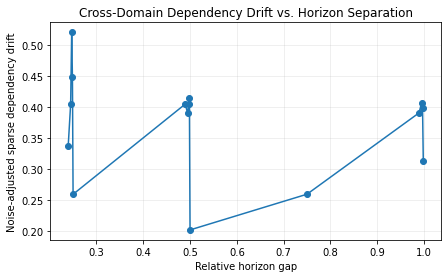

In [19]:

gap_summary = (
    pair_df
    .groupby(
        "relative_gap"
    )
    [
        [
            "K10pct_adjusted_drift",
            "adjusted_rank_drift"
        ]
    ]
    .mean()
    .reset_index()
)

display(
    gap_summary.round(
        4
    )
)

plt.figure(
    figsize=(7, 4)
)

plt.plot(
    gap_summary[
        "relative_gap"
    ],
    gap_summary[
        "K10pct_adjusted_drift"
    ],
    marker="o"
)

plt.xlabel(
    "Relative horizon gap"
)

plt.ylabel(
    "Noise-adjusted sparse dependency drift"
)

plt.title(
    "Cross-Domain Dependency Drift vs. Horizon Separation"
)

plt.grid(
    alpha=0.25
)

plt.show()


## 18. Sparse drift vs. full-rank drift

,dataset,pred_len,K10pct_adjusted_drift,adjusted_rank_drift
0,Electricity,96,0.4688,0.1119
1,Electricity,192,0.4308,0.0820
2,Electricity,336,0.4125,0.0701
3,Electricity,720,0.4978,0.1251
4,Weather,96,0.4603,0.1159
5,Weather,192,0.3889,0.1140
6,Weather,336,0.3413,0.1046
7,Weather,720,0.0794,-0.0453
8,Solar,96,0.6401,0.6496
9,Solar,192,0.5910,0.6800


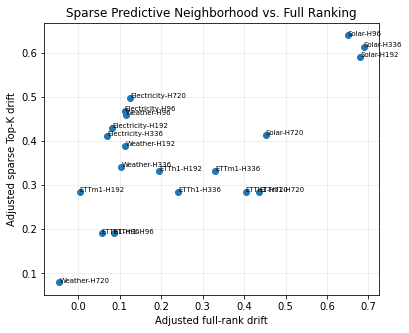

In [20]:

comparison_df = endpoint_df[
    [
        "dataset",
        "pred_len",
        "K10pct_adjusted_drift",
        "adjusted_rank_drift"
    ]
].copy()

display(
    comparison_df.round(
        4
    )
)

plt.figure(
    figsize=(6, 5)
)

plt.scatter(
    comparison_df[
        "adjusted_rank_drift"
    ],
    comparison_df[
        "K10pct_adjusted_drift"
    ]
)

for _, row in (
    comparison_df.iterrows()
):

    plt.annotate(
        f"{row['dataset']}-H{int(row['pred_len'])}",
        (
            row[
                "adjusted_rank_drift"
            ],
            row[
                "K10pct_adjusted_drift"
            ]
        ),
        fontsize=7
    )

plt.xlabel(
    "Adjusted full-rank drift"
)

plt.ylabel(
    "Adjusted sparse Top-K drift"
)

plt.title(
    "Sparse Predictive Neighborhood vs. Full Ranking"
)

plt.grid(
    alpha=0.25
)

plt.show()


## 19. Dataset-level summary for next forecasting experiment

In [21]:

dataset_summary = (
    endpoint_df
    .groupby(
        "dataset"
    )
    .agg(
        mean_sparse_drift=(
            "K10pct_adjusted_drift",
            "mean"
        ),
        max_sparse_drift=(
            "K10pct_adjusted_drift",
            "max"
        ),
        mean_positive_target_fraction=(
            "K10pct_positive_target_fraction",
            "mean"
        ),
        strong_ci_conditions=(
            "K10pct_adjusted_ci_low",
            lambda s:
                int(
                    (
                        s > 0
                    ).sum()
                )
        ),
        mean_rank_drift=(
            "adjusted_rank_drift",
            "mean"
        )
    )
    .reset_index()
)

dataset_summary[
    "priority_for_forecasting_test"
] = (
    dataset_summary[
        "mean_sparse_drift"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

dataset_summary = (
    dataset_summary
    .sort_values(
        [
            "priority_for_forecasting_test"
        ]
    )
)

display(
    dataset_summary.round(
        4
    )
)

dataset_summary.to_csv(
    OUTPUT_DIR
    /
    "dataset_priority_for_forecasting.csv",
    index=False
)


,dataset,mean_sparse_drift,max_sparse_drift,mean_positive_target_fraction,strong_ci_conditions,mean_rank_drift,priority_for_forecasting_test
3,Solar,0.5646,0.6401,0.9781,4,0.6174,1
2,Electricity,0.4525,0.4978,0.9704,4,0.0973,2
4,Weather,0.3175,0.4603,0.6548,3,0.0723,3
0,ETTh1,0.2738,0.3333,0.5000,4,0.2245,4
1,ETTm1,0.2738,0.3333,0.4643,3,0.2143,5


# 20. Interpretation

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.
